# Forward PINN for Darcy Flow Below a Reservoir

Goal: build a **forward Physics-Informed Neural Network** for the hydraulic head field `h(x, y)`.

Important distinction:

- The Excel files are useful for **visualizing the problem** and later checking your result.
- The forward PINN loss should use **only the PDE and boundary conditions**, not the measured/generated head values.

This notebook is intentionally written as a scaffold. Some PyTorch pieces are left as `TODO` so you can implement the model yourself.


# 0. Imports

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.interpolate import griddata

import torch
import torch.nn as nn
import random


## set the same random seed for getting same reults in each running
random.seed(1)
np.random.seed(1)
torch.manual_seed(1)

## use GPU to train or mps
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# 1. Plot data

The filename pattern is:

```text
h1_h2_hd.xlsx
```

where:

- `h1` is the reservoir head,
- `h2` is the downstream catchment head,
- `hd` is the embedded wall depth.

For a forward PINN, we do **not** train on `FINIT`; here we only inspect it so we understand the geometry and have something to compare with after training.

We choose to base ourselves on the dataset
20_5_25.xlsx


Text(0.5, 1.0, 'Scatter Plot of Water Dam Data')

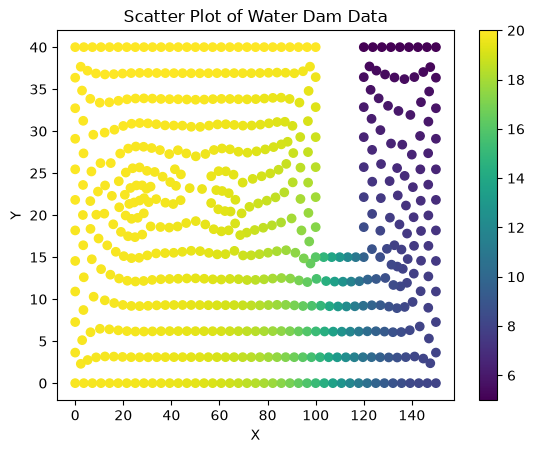

In [3]:
numericldata = pd.read_excel('/Users/hervesv/Documents/CloudDrive/Fac/M1/RWTH_ML/Dam Flow/heads/20_5_25.xlsx',header=0)
X = numericldata['X'].to_numpy()
Y = numericldata['Y'].to_numpy()
h = numericldata['FINIT'].to_numpy()

fig, ax = plt.subplots()
    
scatter = ax.scatter(X, Y, c=h, cmap='viridis')
plt.colorbar(scatter)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Scatter Plot of Water Dam Data')

### Make it into a continous map of h values

In [22]:
# Geometry of problem
h1 = 20
h2 = 5
hd = 25

L = 150

y_top = 40 # top of aquifer
y_bot = 0  # bottom of aquifer
x_left = 0  # left boundary of aquifer
x_right = L   # right boundary of aquifer

x_dleft = 100   # left boundary of dam
x_dright = 120  # right boundary of dam
y_dbot = 40 - hd    # bottom of dam

def interpolate_head(X, Y, h, 
                     grid_res=(300, 100),
                     domain_bounds=(x_left, x_right, y_bot, y_top),
                     dam_bounds=(x_dleft, x_dright, y_dbot, y_top),
                     method="linear"):
    
    x_min, x_max, y_min, y_max = domain_bounds
    num_x, num_y = grid_res

    # Generate regular 2D grid
    xi = np.linspace(x_min, x_max, num_x)
    yi = np.linspace(y_min, y_max, num_y)
    grid_x, grid_y = np.meshgrid(xi, yi)

    # Interpolate scattered points
    grid_h = griddata((X,Y), h, (grid_x, grid_y), method=method)

    # Mask out dam region
    x_dl, x_dr, y_db, y_dt = dam_bounds
    dam_mask = (grid_x >= x_dl) & (grid_x <= x_dr) & (grid_y >= y_db) & (grid_y <= y_dt)
    # Replace all h values within the dam area with nan
    grid_h[dam_mask] = np.nan

    return grid_x, grid_y, grid_h


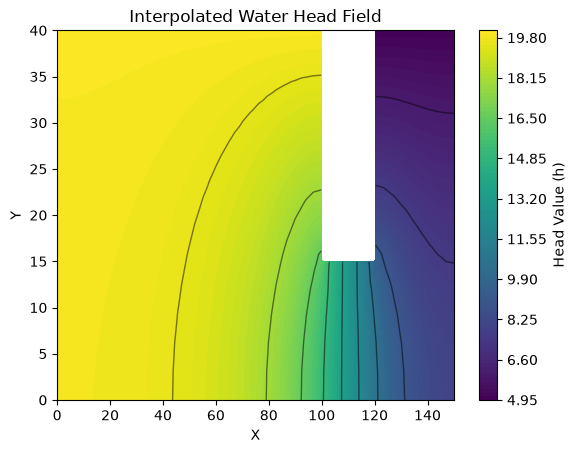

In [23]:
grid_X, grid_Y, grid_h = interpolate_head(X, Y, h)

fig, ax = plt.subplots()
contour = ax.contourf(grid_X, grid_Y, grid_h, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(grid_X, grid_Y, grid_h, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field')
plt.show()

## 3. Nondimensionalize the Governing Equation

The dimensional PDE is Laplace's equation:

$$
\Delta h = \frac{\partial^2 h}{\partial x^2} + \frac{\partial^2 h}{\partial y^2} = 0.
$$

Choose one length scale, for example the total horizontal length:

$$
L = 150\;\text{m}.
$$

Define dimensionless coordinates and head:

$$
\hat{x}=\frac{x}{L}, \qquad \hat{y}=\frac{y}{L}, \qquad
H = \frac{h-h_2}{h_1-h_2}.
$$

Then:

$$
h = h_2 + (h_1-h_2)H.
$$

Because `h2` and `(h1-h2)` are constants, the PDE becomes:

$$
\frac{\partial^2 H}{\partial \hat{x}^2} +
\frac{\partial^2 H}{\partial \hat{y}^2}=0.
$$

Boundary heads become simple:

$$
H=1 \quad \text{on the reservoir boundary},
$$

$$
H=0 \quad \text{on the downstream catchment boundary}.
$$

Impermeable boundaries satisfy no-flow, so the normal derivative is zero:

$$
\nabla H \cdot n = 0.
$$


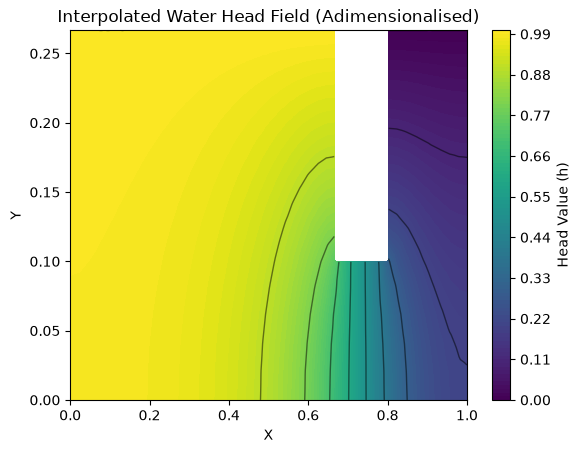

In [27]:
def to_hat_xy(xy):
    """Convert dimensional coordinates [m] to nondimensional coordinates."""
    return xy / L

def to_hat_head(h):
    return (h-h2)/(h1-h2)

def from_hat_head(H):
    """Convert nondimensional head H back to dimensional head h [m]."""
    return h2 + (h1 - h2) * H

grid_X_hat, grid_Y_hat, grid_h_hat = to_hat_xy(grid_X), to_hat_xy(grid_Y), to_hat_head(grid_h)

fig, ax = plt.subplots()
contour = ax.contourf(grid_X_hat, grid_Y_hat, grid_h_hat, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(grid_X_hat, grid_Y_hat, grid_h_hat, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field (Adimensionalised)')
plt.show()

# 2. Draw boundaries and sample collocation and boundary points

Collocation points and boundary condition points. We have three types of boundaries:
1. Boundaries where the value of $h$ is fixed to either $h_1$ or $h_2$
2. Boundaries where $v_x = 0$
3. Boundaries where $v_y = 0$

In [92]:
# normalise domain and dam bounds
# xmin, xmax, ymin, ymax
domain_bounds = np.array([x_left, x_right, y_bot, y_top])
dam_bounds = np.array([x_dleft, x_dright, y_dbot, y_top])

domain_bounds_norm = to_hat_xy(domain_bounds)
dam_bounds_norm = to_hat_xy(dam_bounds)

print(domain_bounds_norm)
print(dam_bounds_norm)

[0.         1.         0.         0.26666667]
[0.66666667 0.8        0.1        0.26666667]


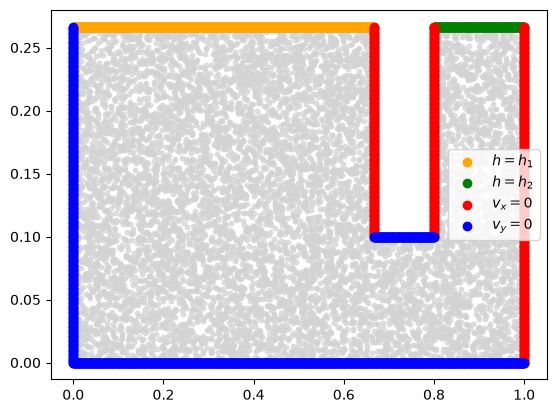

In [132]:

def sample_boundaries(n_density, domain_bounds, dam_bounds):

    x_l, x_r, y_b, y_t = domain_bounds
    x_dl, x_dr, y_db, y_dt = dam_bounds


    x1 = np.linspace(x_l, x_dl, int(n_density * (x_dl-x_l)))
    y1 = np.ones(int(n_density * (x_dl-x_l))) * y_t
    h1 = np.column_stack([x1, y1])

    x2 = np.linspace(x_dr, x_r, int(n_density*(x_r-x_dr)))
    y2 = np.ones(int(n_density*(x_r-x_dr))) * y_t
    h2 = np.column_stack([x2, y2])


    x3 = np.ones(int(n_density*(y_t-y_db))) * x_dl
    y3 = np.linspace(y_db, y_t, int(n_density*(y_t-y_db)))

    x4 = np.ones(int(n_density*(y_t-y_db))) * x_dr
    y4 = np.linspace(y_db, y_t, int(n_density*(y_t-y_db)))

    x7 = np.ones(int(n_density*(y_t))) * x_r
    y7 = np.linspace(y_b, y_t, int(n_density*(y_t)))
    vx0 = np.column_stack([
        np.concatenate([x3, x4, x7]),
        np.concatenate([y3, y4, y7])
    ])

    y5 = np.ones(int(n_density*(x_dr-x_dl))) * y_db
    x5 = np.linspace(x_dl, x_dr, int(n_density*(x_dr-x_dl)))

    y6 = np.zeros(int(n_density*(x_r)))
    x6 = np.linspace(x_l, x_r, int(n_density*(x_r)))

    x8 = np.ones(int(n_density*(y_t))) * x_l
    y8 = np.linspace(y_b, y_t, int(n_density*(y_t)))
    vy0 = np.column_stack([
        np.concatenate([x5, x6, x8]),
        np.concatenate([y5, y6, y8])
    ])

    return {
        "h1": h1,
        "h2": h2,
        "vx0": vx0,
        "vy0": vy0,
    }

def sample_interior_points(num_points, domain_bounds, dam_bounds):
    
    x_l, x_r, y_b, y_t = domain_bounds
    x_dl, x_dr, y_db, y_dt = dam_bounds

    sampled_x = []
    sampled_y = []
    
    while len(sampled_x) < num_points:
        # 1. Generate a random candidate point inside the global bounding box
        x_candidate = np.random.uniform(x_l, x_r)
        y_candidate = np.random.uniform(y_b, y_t)
        
        # 2. Check if the point falls inside the forbidden dam cutout zone
        is_inside_dam = (x_dl <= x_candidate <= x_dr) and (y_db <= y_candidate <= y_t)
        
        # 3. Only keep the point if it is NOT inside the dam
        if not is_inside_dam:
            sampled_x.append(x_candidate)
            sampled_y.append(y_candidate)
            
    return np.column_stack([np.array(sampled_x), np.array(sampled_y)])

# Sample boundary points
bc_density = 1000
bc = sample_boundaries(bc_density, domain_bounds_norm, dam_bounds_norm)


x_bc_h1, y_bc_h1 = bc['h1'][:, 0].reshape(-1, 1), bc['h1'][:, 1].reshape(-1, 1)
x_bc_h2, y_bc_h2 = bc['h2'][:, 0].reshape(-1, 1), bc['h2'][:, 1].reshape(-1, 1)
x_bc_vx0, y_bc_vx0 = bc["vx0"][:, 0].reshape(-1, 1), bc["vx0"][:, 1].reshape(-1, 1)
x_bc_vy0, y_bc_vy0 = bc["vy0"][:, 0].reshape(-1, 1), bc["vy0"][:, 1].reshape(-1, 1)



h1_color = "orange"
h2_color = "green"
vx0_color = "red"
vy0_color = "blue"


plt.scatter(x_bc_h1, y_bc_h1, color=h1_color, label="$h=h_1$")
plt.scatter(x_bc_h2, y_bc_h2, color=h2_color, label="$h=h_2$")
plt.scatter(x_bc_vx0, y_bc_vx0, color=vx0_color, label="$v_x=0$")
plt.scatter(x_bc_vy0, y_bc_vy0, color=vy0_color, label="$v_y=0$")
plt.legend()


# Sample interior points
n_points = 10000
xy_internal = sample_interior_points(n_points, domain_bounds_norm, dam_bounds_norm)
x_internal, y_internal = xy_internal[:,0].reshape(-1, 1), xy_internal[:,1].reshape(-1, 1)



plt.scatter(xy_internal[:,0], xy_internal[:,1], color='lightgray', s=10, label='Interior Sampled Points', alpha=0.7, zorder=-2)


plt.show()





# 4. Define NN model

In [102]:
class MLP(nn.Module):
    # arch = [inputs] + [hidden neurons]*number + [outputs]
    def __init__(self, arch, act):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(arch) - 1):
            layers.append(nn.Linear(arch[i], arch[i + 1]))
            if i < len(arch) - 2:
                layers.append(act())
        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        out = self.model(inputs)
        return out

# 5. Define PINN Loss functions

Our model receives non-dimensional coordinates and predicts non-dimensional head:

$$
(\hat{x}, \hat{y}) \mapsto H_\theta(\hat{x}, \hat{y}).
$$

We have two types of loss: boundary condition loss and PDE loss. Each boundary type has its own loss:





In [130]:
# when head must have a specfic numerical value at boundary
def loss_bc_value(model, x, y, val):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)

    bc_real = torch.full_like(H, val, device=device)
    bc_loss = torch.mean((H - bc_real)**2)
    return bc_loss

# when one of the derivatives must vanish
# dim = 0 or 1 (x or y)
def loss_bc_grad(model, x, y, dim):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    
    u = x if dim==0 else y
    H_u = torch.autograd.grad(H, u,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    
    # derivative should vanish, so nonzero value is taken as loss
    bc_loss = torch.mean((H_u)**2)
    return bc_loss

# PDE loss, from LaPlace equation
def loss_pde(model, x, y):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    H_x = torch.autograd.grad(H, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_xx = torch.autograd.grad(H_x, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_y = torch.autograd.grad(H, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_yy = torch.autograd.grad(H_x, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]

    pde_residual = H_xx + H_yy
    return torch.mean(pde_residual**2)


# when y derivative of head must vanish



# 6. Define network architecture, build it, then train it

Epoch 0: Loss = 1.0149e+00, PDE Loss = 1.8628e-04, BC h1 Loss = 1.0076e+00, BC h2 Loss 2.0809e-03, BC vx0 Loss 0.005069404374808073, BC vy0 Loss 2.8114011456636945e-06
Epoch 100: Loss = 4.0217e-01, PDE Loss = 2.9137e-03, BC h1 Loss = 1.7656e-01, BC h2 Loss 1.6583e-01, BC vx0 Loss 0.052468717098236084, BC vy0 Loss 0.004398632794618607
Epoch 200: Loss = 3.7530e-01, PDE Loss = 3.5483e-03, BC h1 Loss = 1.5222e-01, BC h2 Loss 1.4113e-01, BC vx0 Loss 0.05203251168131828, BC vy0 Loss 0.026367714628577232
Epoch 300: Loss = 3.6631e-01, PDE Loss = 8.4208e-03, BC h1 Loss = 1.4760e-01, BC h2 Loss 1.3469e-01, BC vx0 Loss 0.047084931284189224, BC vy0 Loss 0.028510648757219315
Epoch 400: Loss = 3.6089e-01, PDE Loss = 1.0496e-02, BC h1 Loss = 1.4506e-01, BC h2 Loss 1.3012e-01, BC vx0 Loss 0.04381490498781204, BC vy0 Loss 0.0314047671854496
Epoch 500: Loss = 3.5603e-01, PDE Loss = 1.2984e-02, BC h1 Loss = 1.4241e-01, BC h2 Loss 1.2744e-01, BC vx0 Loss 0.043997108936309814, BC vy0 Loss 0.029199626296758

Text(0.5, 0, 'Epoch')

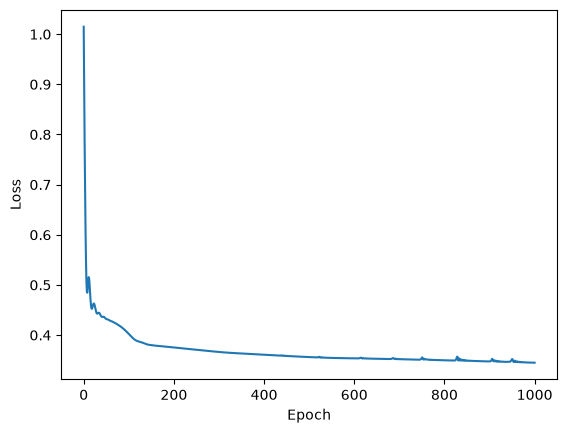

In [159]:
# Create neural network with tanh activation function
layers = [2] + [50]*4 + [1]
model = MLP(layers, nn.Tanh).to(device)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Number of epochs
num_epochs = 1000

pde_weight = 1
bc_weight_1 = 1
bc_weight_2 = 1
bc_weight_3 = 1
bc_weight_4 = 1

losses = []

# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    # Compute losses
    bc_h1_loss = loss_bc_value(model, bc['h1'][:,0].reshape(-1, 1), bc['h1'][:,1].reshape(-1, 1), 1)
    bc_h2_loss = loss_bc_value(model, bc['h2'][:,0].reshape(-1, 1), bc['h2'][:,1].reshape(-1, 1), 0)
    bc_vx0_loss = loss_bc_grad(model, bc['vx0'][:,0].reshape(-1, 1), bc['vx0'][:,1].reshape(-1, 1), dim=0)
    bc_vy0_loss = loss_bc_grad(model, bc['vy0'][:,0].reshape(-1, 1), bc['vy0'][:,1].reshape(-1, 1), dim=1)

    pde_loss = loss_pde(model, x_internal, y_internal)

    # combine losses
    loss = bc_weight_1 * bc_h1_loss + bc_weight_2 * bc_h2_loss + bc_weight_3 * bc_vx0_loss + bc_weight_4 * bc_vy0_loss + pde_weight * pde_loss
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4e}, PDE Loss = {pde_loss.item():.4e}, BC h1 Loss = {bc_h1_loss.item():.4e}, BC h2 Loss {bc_h2_loss.item():.4e}, BC vx0 Loss {bc_vx0_loss}, BC vy0 Loss {bc_vy0_loss}")


epochs = np.linspace(0, num_epochs, len(losses))
plt.plot(epochs, losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

# 7. Visualise output
not working

In [157]:
def remove_dam(grid_x, grid_y, grid_h, dam_bounds):
    x_dl, x_dr, y_db, y_dt = dam_bounds
    dam_mask = (grid_x >= x_dl) & (grid_x <= x_dr) & (grid_y >= y_db) & (grid_y <= y_dt)
    grid_h[dam_mask] = np.nan

    return grid_h

[[0.8065929  0.80468845 0.80275476 ... 0.38121745 0.38097274 0.38072988]
 [0.8064892  0.8046087  0.80269885 ... 0.38078743 0.3805416  0.380298  ]
 [0.8064315  0.80457455 0.8026884  ... 0.3803579  0.38011113 0.37986633]
 ...
 [0.8265492  0.8256573  0.82476497 ... 0.33684453 0.33648676 0.33613133]
 [0.826523   0.8256331  0.82474273 ... 0.33634526 0.33598596 0.33562905]
 [0.82649666 0.8256085  0.82472014 ... 0.33584592 0.33548522 0.3351269 ]]


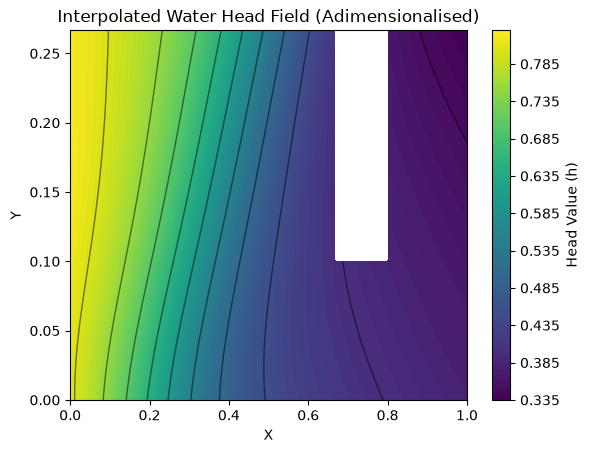

In [160]:
Nx, Ny = 300, 100
x = np.linspace(x_left, x_right, Nx).reshape(-1, 1)
y = np.linspace(y_bot, y_top, Ny).reshape(-1, 1)

x_mesh, y_mesh = np.meshgrid(x, y)

x_mesh_hat, y_mesh_hat = to_hat_xy(x_mesh), to_hat_xy(y_mesh)
xy_hat = np.hstack((x_mesh_hat.reshape(-1, 1), y_mesh_hat.reshape(-1, 1)))
with torch.no_grad():
    H_pre = model(torch.tensor(xy_hat).float().to(device))

H_pre = H_pre.cpu().numpy().reshape(Ny, Nx)

H_pre = remove_dam(x_mesh, y_mesh, H_pre, dam_bounds=dam_bounds)

print(H_pre)

h_pre = from_hat_head(H_pre)

fig, ax = plt.subplots()
contour = ax.contourf(x_mesh_hat, y_mesh_hat, H_pre, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Head Value (h)')
ax.contour(x_mesh_hat, y_mesh_hat, H_pre, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Interpolated Water Head Field (Adimensionalised)')
plt.show()

# Adaptive weights

In [ ]:
class PINN_weights(torch.nn.Module):
    def __init__(
        self,
        model,
        device=torch.device("cpu")
    ):
        super().__init__()
        self.device = device
        self.model = model.to(self.device)

    def net_h(self, x, y):
        inputs = torch.cat((x, y), dim=1)
        h = self.model(inputs)
        return h


    def pde_residual(self, x, t):
        u = self.net_u(x, t)
        u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
        u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
        u_tt = torch.autograd.grad(u_t, t, torch.ones_like(u_t), create_graph=True)[0]

        pde_residual = u_tt - 4 * u_xx
        return pde_residual

    def ic_func(self, x):
        with torch.no_grad():
            return torch.sin(torch.pi * x) + 1/2 * torch.sin(4 * torch.pi * x)

    def adaptive_sampling(self, num_points, base_grid_points, method):
        base_grid_x = base_grid_points[:, 0:1].to(self.device).requires_grad_(True)
        base_grid_t = base_grid_points[:, 1:2].to(self.device).requires_grad_(True)

        self.eval()
        if method == 'gar':
            u = self.net_u(base_grid_x, base_grid_t)

            # calculate gradients to see the steepest prediction points
            u_x = torch.autograd.grad(u, base_grid_x, torch.ones_like(u), create_graph=True, retain_graph=True)[0]
            u_t = torch.autograd.grad(u, base_grid_t, torch.ones_like(u), create_graph=True, retain_graph=True)[0]

            _, idx_u_x = torch.topk(u_x.squeeze().abs(), num_points)
            _, idx_u_t = torch.topk(u_t.squeeze().abs(), num_points)

            idx = torch.cat((idx_u_x, idx_u_t), dim=0)
            idx = torch.unique(idx)

        if method == 'rar':
            pde_residual = self.pde_residual(base_grid_x, base_grid_t)
            _, idx = torch.topk(pde_residual.squeeze().abs(), num_points)

        adaptive_points = base_grid_points[idx, :]
        return adaptive_points

    def calc_jacobian(self, output):
        output = output.view(-1)
        size = output.shape[0]
        # Compute batched gradients w.r.t. all parameters except last layer
        gradients = torch.autograd.grad(output, list(self.parameters())[:-1], grad_outputs=torch.eye(size).to(self.device), is_grads_batched=True, retain_graph=True)

        # Concatenate  gradients into Jacobian matrix
        jacobian = torch.cat([grad.flatten().view(size, -1) for grad in gradients], dim=1)
        return jacobian

    def calc_ntk(self, jacobian, computation_type='trace'):
        """Compute Neural Tangent Kernel metrics from Jacobian matrix."""

        # Define computation methods using Einstein summation
        ntk_operations = {
            'full': lambda jac: torch.einsum('Na,Ma->NM', jac, jac),  # Full NTK matrix
            'diag': lambda jac: torch.einsum('Na,Na->N', jac, jac),   # Diagonal elements
            'trace': lambda jac: torch.einsum('Na,Na->', jac, jac)    # Trace (scalar)
        }

        if computation_type not in ntk_operations:
            raise ValueError(f'Metric "{computation_type}" not supported. '
                            f'Choose from: {list(ntk_operations.keys())}')

        return ntk_operations[computation_type](jacobian)

    def calculate_adaptive_weights(self, loss_residuals, sampling_strategy, batch_size, return_info=False):
        """Compute NTK-based adaptive weights for loss terms."""
        traces, jacs = [], []

        for res in loss_residuals:
            n = len(res)
            if sampling_strategy == "random": # random-batch technique
                idx = np.random.randint(0, n, batch_size) if batch_size < n else slice(None)
                jac = self.calc_jacobian(res[idx])
                norm = batch_size if batch_size < n else n
            elif sampling_strategy == "topres":  # compute the weight using the points with top residuals
                idx = slice(0, batch_size) if batch_size < n else slice(None)
                jac = self.calc_jacobian(res[idx])
                norm = batch_size if batch_size < n else n
            elif sampling_strategy == "mini": # compute the weight using mini-batch technique
                trace = 0
                for i in range(0, n, batch_size):
                    jac = self.calc_jacobian(res[i:i + batch_size])
                    trace += self.calc_ntk(jac, computation_type='trace').item()
                traces.append(trace / n)
                if return_info:
                    jacs.append(jac)
                continue
            elif sampling_strategy == "full":
                jac = self.calc_jacobian(res)
                norm = n
            else:
                raise ValueError(f"Unknown sampling strategy: {sampling_strategy}. Must be one of 'random', 'topres', 'mini', or 'full'.")

            trace = self.calc_ntk(jac, computation_type='trace').item()
            traces.append(trace / norm)
            if return_info:
                jacs.append(jac)

        traces = np.array(traces)
        weights = traces.sum() / traces
        return (weights, jacs) if return_info else weights

    def predict(self, x, t):
        self.model.eval()
        with torch.no_grad():
            x = x.to(self.device)
            t = t.to(self.device)
            return self.net_u(x, t).cpu().numpy()

    def evaluate(self, dom_points, ic_points, bc_points, adap_points, num_x=100, num_t=100):

        self.model.eval()

        # Prepare testing grid
        x_test = torch.linspace(0, 1, num_x).reshape(-1, 1).to(self.device)
        t_test = torch.linspace(0, 1, num_t).reshape(-1, 1).to(self.device)
        x_grid, t_grid = torch.meshgrid(x_test.squeeze(), t_test.squeeze(), indexing='ij')
        x_grid_flat = x_grid.reshape(-1, 1)
        t_grid_flat = t_grid.reshape(-1, 1)

        # Predict using the trained model
        u_pred = self.predict(x_grid_flat, t_grid_flat).reshape(num_x, num_t)
        # Analytical solution
        # u_analytical = u_wave(x_grid_flat.cpu().numpy(), t_grid_flat.cpu().numpy()).reshape(num_x, num_t)
        u_real = u_real_wave(x_grid_flat.cpu().numpy(), t_grid_flat.cpu().numpy()).reshape(num_x, num_t)

        # Calculate errors
        diff = np.abs(u_pred - u_real)
        #Calculate L2 normalized relative error
        L2_relative_error = np.linalg.norm(diff) / np.linalg.norm(u_real)
        print(f'L2 Normalized Relative Error: {L2_relative_error:.4f}')

        # Calculate accuracy as 1 - normalized RMSE
        acc = 1 - np.sqrt(np.mean(diff ** 2))

        fig, axes = plt.subplots(1, 4, figsize=(20, 4))
        axes = axes.flatten()

        axes[0].imshow(u_pred, aspect='auto', origin='lower', extent=[0.0, 1.0, 0.0, 1], cmap="rainbow")
        axes[0].set_title(f"PINN Prediction")

        axes[1].imshow(u_real, aspect='auto', origin='lower', extent=[0, 1, 0, 1], cmap="rainbow")
        axes[1].set_title("Reference Solution")

        axes[2].imshow(diff, aspect='auto', origin='lower', extent=[0.0, 1.0, 0.0, 1], cmap="binary")
        axes[2].set_title(f"Absolute Error, Accuracy: {acc:.3f}")

        axes[3].scatter(dom_points[:, 1].cpu().numpy(), dom_points[:, 0].cpu().numpy(), c="steelblue", label="collcations", s=2)
        if adap_points is not None:
            axes[3].scatter(adap_points[:, 1].cpu().numpy(), adap_points[:, 0].cpu().numpy(), c="yellowgreen", label="adaptive points", marker="x", s=2)
        axes[3].scatter(bc_points[:, 1].cpu().numpy(), bc_points[:, 0].cpu().numpy(), c="crimson", s=2, label="bc")
        axes[3].scatter(ic_points[:, 1].cpu().numpy(), ic_points[:, 0].cpu().numpy(), c="orange", s=2, label="ic")
        axes[3].set_title("Sampled Points")

        plt.colorbar(axes[0].images[0], ax=axes[0])
        plt.colorbar(axes[1].images[0], ax=axes[1])
        plt.colorbar(axes[2].images[0], ax=axes[2])
        plt.tight_layout()